# Practice: question answering with retrieval

In this homework you will build a retrieval-based question answering system, one component at a time.

_Okay, realistically, there's like, two components, but technically it's one component at a time._


![img](https://www.cs.upc.edu/~mlatifi/index_files/qa-logo.jpg)



There are two parts to this type of systems: a retriever and a generator.
- the retriever subsystem searches for similar texts from a given databse, e.g. wikipedia
- the generator uses the texts found by the retriever to generate an answer in natural language

_this seminar is based on original notebook by [Oleg Vasilev](https://github.com/Omrigan/)_



In [ ]:
# !git clone https://github.com/giaphu39/nlp_course.git

In [1]:
%cd /kaggle/working/nlp_course/week09_retrieval

/kaggle/working/nlp_course/week09_retrieval


In [2]:
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Part 0: the dataset

Before we train anything, let's take a look at the question answering data that we can use. There are several popular datasets, e.g. TriviaQA for trivia questions or GSM8K for math. Today's data is Stanford Question Answering Dataset (SQuAD). Given a paragraph of text and a question, our model's task is to select a snippet that answers the question.

We are not going to solve the full task today. Instead, we'll train a model to __select the sentence containing answer__ among several options.

As usual, you are given an utility module with data reader and some helper functions

In [3]:
# %pip install --quiet transformers==4.36.2 accelerate==0.24.0 sentencepiece==0.1.99 optimum==1.13.2 auto-gptq==0.4.2
# ^-- if this fails, remove the specific version and install latest ones: pip install --update transformers accelerate ...
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2023/week_extra/retrieval/data.py -O data.py
!wget https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v2.0.json -O squad-v2.0.json 2> log

--2026-08-07 17:41:54--  https://raw.githubusercontent.com/yandexdataschool/nlp_course/2023/week_extra/retrieval/data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3553 (3.5K) [text/plain]
Saving to: ‘data.py’

data.py             100%[===================>]   3.47K  --.-KB/s    in 0s      

2026-08-07 17:41:54 (59.7 MB/s) - ‘data.py’ saved [3553/3553]



In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
import data
# backup download link: https://www.dropbox.com/s/q4fuihaerqr0itj/squad.tar.gz?dl=1
train, test = data.build_dataset('./squad-v2.0.json')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
pid, question, options, correct_indices, wrong_indices = train.iloc[40] # : Lấy ra dòng thứ 41 (vì index trong Python bắt đầu từ 0) của một bảng dữ liệu Pandas DataFrame có tên là train
print('QUESTION', question, '\n')
print('TEXT SENTENCES')
for i, cand in enumerate(options):
    print(['[ ]', '[v]'][i in correct_indices], cand)

QUESTION Where did Beyonce get her name from? 

TEXT SENTENCES
[ ] Beyoncé Giselle Knowles was born in Houston, Texas, to Celestine Ann "Tina" Knowles (née Beyincé), a hairdresser and salon owner, and Mathew Knowles, a Xerox sales manager.
[v] Beyoncé's name is a tribute to her mother's maiden name.
[ ] Beyoncé's younger sister Solange is also a singer and a former member of Destiny's Child.
[ ] Mathew is African-American, while Tina is of Louisiana Creole descent (with African, Native American, French, Cajun, and distant Irish and Spanish ancestry).
[ ] Through her mother, Beyoncé is a descendant of Acadian leader Joseph Broussard.
[ ] She was raised in a Methodist household.


### Pre-trained BERT
_(but you guessed it)_

We've already solved quite a few tasks from scratch, training our own embeddings and convolutional/recurrent layers. However, one can often achieve higher quality by using pre-trained models. We will default to the good ol' [BERT](https://arxiv.org/abs/1810.04805), though, you are free to use any [other model](https://huggingface.co/models) as you see fit.


In [7]:
from transformers import AutoTokenizer, AutoModel, pipeline

model_name = 'sentence-transformers/bert-base-nli-mean-tokens'
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/bert-base-nli-mean-tokens
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
# just a reminder: here's how it works
dummy_lines = [
    "How old are you?",                                                 # 0
    "In what mythology do two canines watch over the Chinvat Bridge?",  # 1
    "I'm sorry, okay, I'm not perfect, but I'm trying.",                # 2
    "What is your age?",                                                # 3
    "Beware, for I am fearless, and therefore powerful.",               # 4
]
# Các mô hình ngôn ngữ như BERT có giới hạn về độ dài đầu vào (thường là tối đa 512 token).
# Khi bạn đặt truncation=True, nếu một câu trong dummy_lines quá dài và vượt quá giới hạn tối đa này, Tokenizer sẽ tự động cắt bỏ phần đuôi của câu đó để đảm bảo mô hình không bị lỗi khi xử lý.

with torch.no_grad():
    batch_tensors = tokenizer(dummy_lines, padding=True, truncation=True, return_tensors="pt")
    out = bert(**batch_tensors) # ** (double asterisk) là toán tử giải nén từ điển # Biến batch_tensors được trả về từ tokenizer thường là một dạng dictionary (từ điển) chứa các tensor như: input_ids, token_type_ids, và attention_mask.
    token_embs = out.last_hidden_state # Lấy ra biểu diễn vector (embedding) của từng token (từng từ) ở lớp ẩn cuối cùng của mô hình. Tensor này thường có kích thước (số_lượng_câu, độ_dài_câu, kích_thước_ẩn_ví_dụ_768).
    cls_embs = out.pooler_output # Lấy ra vector đại diện của token đặc biệt [CLS] (token đầu tiên của mỗi câu). Biểu diễn này thường được dùng làm vector đại diện cho toàn bộ câu trong các bài toán phân loại văn bản.
    del out # Xóa biến out khỏi bộ nhớ. Điều này giúp dọn dẹp và giải phóng RAM/VRAM ngay lập tức vì chúng ta đã trích xuất xong 2 thông tin cần thiết ở trên.

# attention_mask là một ma trận chứa các số 1 (ứng với từ thật) và 0 (ứng với phần padding được thêm vào cho bằng độ dài).
# [..., None] (hay unsqueeze) dùng để thêm một chiều mới vào cuối ma trận này, biến nó thành kích thước (số_lượng_câu, độ_dài_câu, 1) để có thể nhân đồng đều với token_embs (3 chiều).
mask = batch_tensors['attention_mask'][..., None].to(torch.float32)
naive_phrase_embs = (token_embs * mask).sum(1) / mask.sum(1) # Kết quả thu được naive_phrase_embs là các vector nhúng (embeddings) đại diện cho ngữ nghĩa của từng câu trong danh sách dummy_lines.

# token_embs vẫn chứa các biểu diễn của từ không có trong câu nên dùng mask để chú ý vào từ có trong câu thôi

vd: token_embs có shape là (5, 12, 768)
(5 câu, mỗi câu dài 12 tokens, mỗi token là một vector 768 chiều). và batch_tensors['attention_mask'] lúc đầu có shape là (5, 12). Bạn không thể nhân trực tiếp một khối 3 chiều (5, 12, 768) với một mặt phẳng 2 chiều (5, 12). Vì vậy, đoạn code dùng [..., None] để "kéo giãn" mask ra thành 3 chiều:

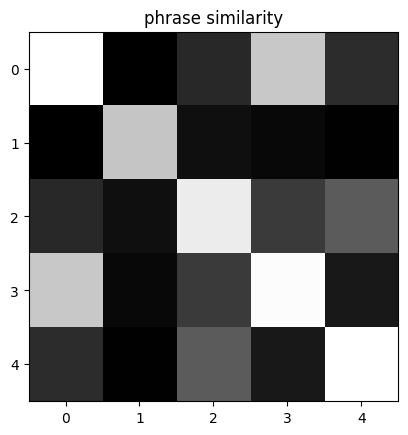

In [9]:
plt.title('phrase similarity')
plt.imshow((naive_phrase_embs @ naive_phrase_embs.t()).cpu().data.numpy(), interpolation='none', cmap='gray')

màu trắng là chính nó nên tương đồng max, đen là không tương đồng, trắng dần thì tương đồng tăng dần

As you can see, __the strongest similarity is between lines 0 and 3__. Indeed they correspond to "How old are you?" and "What is your age?"

### Retriever Model (2 points)

Our goal for today is to build a model that measures similarity between question and answer. In particular, it maps both question and answer into fixed-size vectors such that:

Our model is a pair of $V_q(q)$ and $V_a(a)$ - networks that turn phrases into vectors.

__Objective:__ Question vector $V_q(q)$ should be __closer__ to correct answer vectors $V_a(a^+)$ than to incorrect ones $V_a(a^-)$ .

Both vectorizers can be anything you wish. For starters, let's use a couple of dense layers on top of the pre-trained encoder.




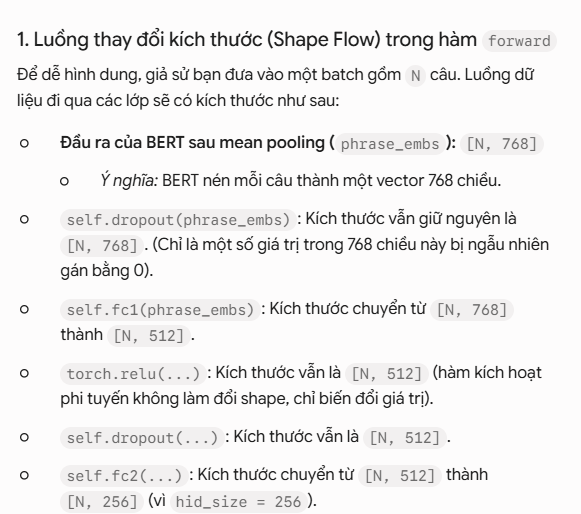

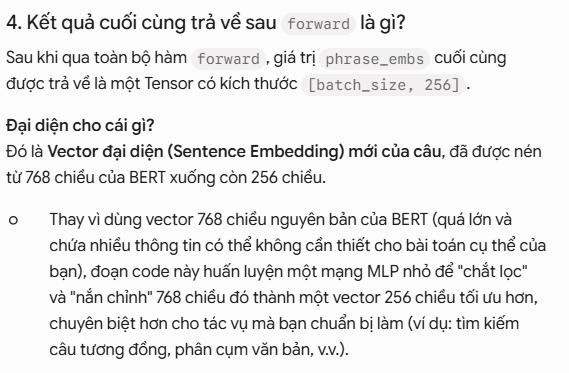

In [10]:
class Vectorizer(nn.Module):
    def __init__(self, hid_size=256, bert=bert):
        """ Mạng feedforward nhỏ đặt trên bộ mã hóa tiền huấn luyện (BERT). 2-3 lớp là đủ """
        super().__init__()
        self.bert = bert
        self.hid_size = hid_size

        # Định nghĩa vài lớp áp lên BERT tiền huấn luyện.
        # BERT base trả về vector 768 chiều cho mỗi token.
        # Ta xây 2 lớp tuyến tính: 768 -> 512 -> hid_size (256).
        # Lưu ý: lớp cuối cùng phải là lớp tuyến tính thuần (không có activation).
        self.fc1 = nn.Linear(768, 512) # 512 neuron có 768 chiều (768 là flatten của feature sau extract bằng BERT)
        self.fc2 = nn.Linear(512, self.hid_size) # 256 neuron cho 512 chiều 

        # Dropout >= 10% (yêu cầu của bài) để chống overfitting.
        self.dropout = nn.Dropout(0.2)

        # Đóng băng BERT: chỉ dùng nó như bộ trích đặc trưng cố định (feature extractor).
        # Chỉ các lớp MLP phía trên được huấn luyện -> tiết kiệm bộ nhớ và thời gian.
        for param in self.bert.parameters():
            param.requires_grad_(False)
        self.bert.eval()

    def forward(self, input_phrases):
        """
        Áp vectorizer. Tự do dùng dropout và các kỹ thuật khác.
        :param input_phrases: danh sách chuỗi, [batch_size]
        :returns: vector dự đoán cho các câu, [batch_size, output_size]

        Gợi ý: nên dùng dropout; khi self.training=True thì dropout được bật.
        Gợi ý 2: nên dùng torch.no_grad để không huấn luyện lại BERT trong những lần chạy đầu.
        """

        # Tokenize batch câu đầu vào (dùng tokenizer toàn cục đã nạp ở phần trên)
        batch_tensors = tokenizer(
            input_phrases,
            padding=True,
            truncation=True,
            return_tensors="pt",
        ).to(next(self.bert.parameters()).device)  # đưa lên cùng device với BERT

        # Lấy embedding của từng token. Bọc trong no_grad để BERT không được huấn luyện
        # (tránh tốn bộ nhớ / thời gian; chỉ lớp MLP phía trên mới được cập nhật).
        with torch.no_grad():
            self.bert.eval()  # đảm bảo BERT luôn ở chế độ eval
            token_embs = self.bert(**batch_tensors).last_hidden_state

        # Mean pooling: lấy trung bình có trọng số theo attention mask
        # để gộp các token thành một vector đại diện cho cả câu.
        mask = batch_tensors["attention_mask"][..., None].to(torch.float32)
        phrase_embs = (token_embs * mask).sum(1) / mask.sum(1)

        # Đưa vector câu qua các lớp MLP phía trên (các lớp này được huấn luyện).
        phrase_embs = self.dropout(phrase_embs) # tắt bớt cho lần lặp để xem xét nhiều feature khác nhau (nên dropout ở đầu sau feature extract)
        phrase_embs = torch.relu(self.fc1(phrase_embs))
        phrase_embs = self.dropout(phrase_embs)
        # Lớp cuối là tuyến tính thuần (linear activation) theo yêu cầu của bài.
        phrase_embs = self.fc2(phrase_embs)
        return phrase_embs


In [11]:
question_vectorizer = Vectorizer()
answer_vectorizer = Vectorizer()

In [12]:
question_vectorizer.train(False)
out1 = question_vectorizer(dummy_lines)
out2 = question_vectorizer(dummy_lines)
assert tuple(out1.shape) == (5, question_vectorizer.hid_size)
assert torch.allclose(out1, out2, atol=1e-5, rtol=0), "Make sure your model disables dropout if training == False"
print("Well done!")

Well done!


### Retriever training: minibatches

Our model learns on triples $(q, a^+, a^-)$:
* q - <b>q</b>uestion
* (a+) - correct <b>a</b>nswer
* (a-) - wrong <b>a</b>nswer

Below you will find a generator that samples such triples from data.

Hàm iterate_minibatches này đóng vai trò là một Data Generator (Bộ tạo dữ liệu). Nhiệm vụ của nó là lấy tập dữ liệu lớn (dataset) của bạn và cắt nhỏ ra thành các lô (batch) để đưa vào mô hình huấn luyện từ từ.

Đặc biệt, nó tạo ra dữ liệu dưới dạng Triplet (bộ 3): [Câu hỏi, Câu trả lời đúng, Câu trả lời sai]. Đây là cấu trúc dữ liệu chuẩn để huấn luyện mô hình học theo kiểu Triplet Loss (kéo câu đúng lại gần câu hỏi, đẩy câu sai ra xa).

In [13]:
import random

def iterate_minibatches(data, batch_size, shuffle=True, cycle=False): # data dạng df, batch_size là số lượng câu muốn lấy ra trong 1 lần, shuffle có xáo trộn data trước khi cắt lô không, cycle: true thì khi đọc hết dữ liệu thì vòng lại từ đầu để lấy ra train tiếp (chỉ dừng khi early stoping chứ không đặt thì chạy như While(true))
    """
    Generates minibatches of triples: {questions, correct answers, wrong answers}
    If there are several wrong (or correct) answers, picks one at random.
    """
    indices = np.arange(len(data)) # Tạo một mảng chứa các chỉ số (index) từ 0 đến tổng số dòng dữ liệu - 1
    while True:
        if shuffle:
            indices = np.random.permutation(indices) # Từ permutation trong tiếng Anh nghĩa là "hoán vị". Lệnh np.random.permutation(mảng) đơn giản là lấy một mảng, tráo đổi vị trí các phần tử bên trong nó một cách ngẫu nhiên, và trả về một mảng mới. do đây là mảng index nên hoán đổi vị trí được vd: [0, 1, 2, 3, 4] thành [3, 0, 4, 1, 2]
        for batch_start in range(0, len(indices), batch_size):
            batch_indices = indices[batch_start: batch_start + batch_size]
            batch = data.iloc[batch_indices]
            questions = batch['question'].values
            correct_answers = np.array([
                row['options'][random.choice(row['correct_indices'])] # bóc ra đúng 1 vị trí đáp án đúng trong tập đáp án ứng với câu hỏi 
                for i, row in batch.iterrows()
            ])
            wrong_answers = np.array([
                row['options'][random.choice(row['wrong_indices'])] # tương tự bóc ra 1 cái sai
                for i, row in batch.iterrows()
            ])

            yield { # nghĩa là bên ngoài nhận batch 1 đem đi train loss, backward, step... xong xuôi nó quay lại đòi batch 2 bằng lệnh next thì hàm sẽ tiếp tục chạy trong vòng for
                'questions' : questions,
                'correct_answers': correct_answers,
                'wrong_answers': wrong_answers,
            } # yield sẽ "tạm dừng" hàm và trả về 1 dictionary chứa batch dữ liệu hiện tại. Lần tới khi bạn gọi vòng lặp (như lệnh next(dev_batches) hoặc trong vòng lặp for), nó sẽ tiếp tục chạy từ dòng này để tạo ra batch tiếp theo.
        if not cycle:
            break

In [14]:
dummy_batch = next(iterate_minibatches(train.sample(3), 3)) # rút ra 3 câu từ data lớn và cho lặp batchsize = 3 -> nghĩa là chỉ đụng 1 yield
print(dummy_batch)

{'questions': array(['What station first introduced the tagline "everyone at work can agree on"?',
       'What name did people opposed to the Bolsheviks use for the Soviet state?',
       'How many Israelis speak French?'], dtype=object), 'correct_answers': array(['Many stations in the soft AC format capitalize on its appeal to office workers (many of them females aged 25–54, a key advertiser demographic), and brand themselves as stations "everyone at work can agree on" (KOST originated that phrase as a primary tagline, and other soft AC stations have followed suit).',
       'Meanwhile, anti-Bolsheviks coined the mocking label "Sovdepia" for the nascent state of the "Soviets of Workers\' and Peasants\' Deputies".',
       'French is spoken by around 700,000 Israelis, mostly originating from France and North Africa (see Maghrebi Jews).'],
      dtype='<U307'), 'wrong_answers': array(['Other popular names for the format include "Warm", "Sunny", "Bee" (or "B") and (particularly in Canad

### Retriever training: loss function (2 points)
We want our vectorizers to put correct answers closer to question vectors and incorrect answers farther away from them. One way to express this is to use is Pairwise Hinge Loss _(aka Triplet Loss)_.

$$ L = \frac 1N \underset {q, a^+, a^-} \sum max(0, \space \delta - sim[V_q(q), V_a(a^+)] + sim[V_q(q), V_a(a^-)] )$$

, where
* sim[a, b] is some similarity function: dot product, cosine or negative distance
* δ - loss hyperparameter, e.g. δ=1.0. If sim[a, b] is linear in b, all δ > 0 are equivalent.


This reads as __Correct answers must be closer than the wrong ones by at least δ.__

![img](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/margin.png)
<center>_image: question vector is green, correct answers are blue, incorrect answers are red_</center>


Note: in effect, we train a Deep Semantic Similarity Model [DSSM](https://www.microsoft.com/en-us/research/project/dssm/).

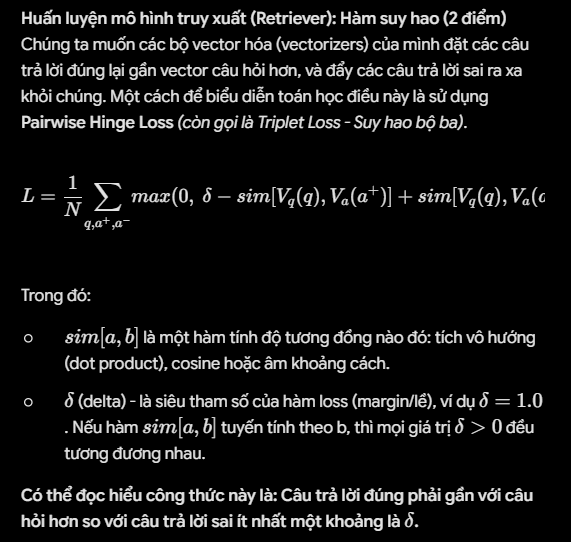

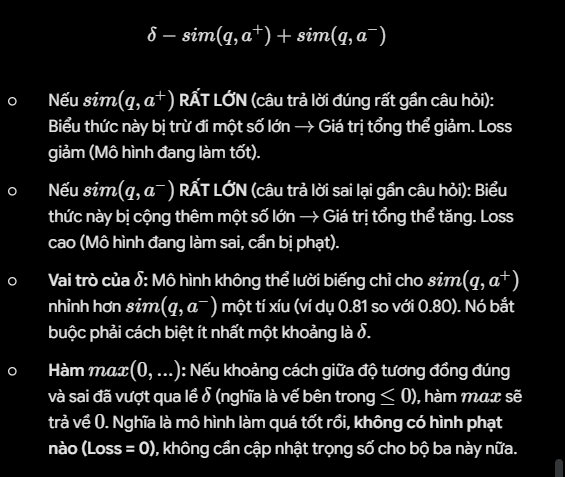

In [15]:
def similarity(a, b):
    """ Tích vô hướng (dot product) được dùng làm hàm tương tự """
    # (batch, dim) và (batch, dim) -> (batch,) # batch là số câu, dim là số đặc trưng ứng với câu đó 
    # Nhân theo từng phần tử rồi cộng dồn theo chiều đặc trưng (dim).
    return (a * b).sum(dim=1) #tính tích chập rồi tổng lại theo đặc trưng => mỗi câu là 1 con số 


def compute_loss(question_vectors, correct_answer_vectors, wrong_answer_vectors, delta=1.0):
    """
    Tính triplet loss theo công thức phía trên.
    Dùng hàm similarity ở trên cho sim[a, b].
    :param question_vectors: float32[batch_size, vector_size]
    :param correct_answer_vectors: float32[batch_size, vector_size]
    :param wrong_answer_vectors: float32[batch_size, vector_size]
    :returns: loss cho từng dòng trong batch, float32[batch_size]
    Gợi ý: tính max(0, *) bằng torch.relu :)
    """
    # L = max(0, delta - sim[Vq(q), Va(a+)] + sim[Vq(q), Va(a-)])
    # Công thức đọc là: câu trả lời đúng phải gần câu hỏi hơn câu trả lời sai ít nhất delta.
    sim_pos = similarity(question_vectors, correct_answer_vectors)  # độ tương tự với đáp án đúng
    sim_neg = similarity(question_vectors, wrong_answer_vectors)    # độ tương tự với đáp án sai
    return torch.relu(delta - sim_pos + sim_neg) # đi ngược lại loss thì ngược dấu nên
    # optimizer sẽ đẩy sim_pos tăng, sim_neg giảm dần để giảm loss, delta để cho sim_pos và sim_neg cách xa nhau chứ không chỉ lệnh -0.01 thì tính là loss = 0, kiểu thêm và để cho nó tối ưu cách nhau 1 khoảng delta


In [16]:
dummy_v1 = torch.tensor([[0.1, 0.2, -1], [-1.2, 0.6, 1.0]], dtype=torch.float32)
dummy_v2 = torch.tensor([[0.9, 2.1, -6.6], [0.1, 0.8, -2.2]], dtype=torch.float32)
dummy_v3 = torch.tensor([[-4.1, 0.1, 1.2], [0.3, -1, -2]], dtype=torch.float32)

assert np.allclose(similarity(dummy_v1, dummy_v2).data.numpy(), [7.11, -1.84])
assert np.allclose(compute_loss(dummy_v1, dummy_v2, dummy_v3, delta=5.0).data.numpy(), [0.0, 3.88])

Once loss is working, let's train our model by our usual means.

In [17]:
# ta cũng tính recall: tỷ lệ khi a^+ gần q hơn a^-
def get_recall(questions, correct_answers, wrong_answers):
    
    # SỬA Ở ĐÂY: Ép kiểu numpy.ndarray về list chuẩn của Python
    questions = list(questions)
    correct_answers = list(correct_answers)
    wrong_answers = list(wrong_answers)

    # Vector hóa câu hỏi bằng question_vectorizer
    v_questions = question_vectorizer(questions)
    # Vector hóa câu trả lời đúng và sai bằng answer_vectorizer
    v_correct = answer_vectorizer(correct_answers)
    v_incorrect = answer_vectorizer(wrong_answers)

    # Đúng nếu độ tương tự giữa q và a+ lớn hơn độ tương tự giữa q và a-
    correct_is_closer = similarity(v_questions, v_correct) > similarity(v_questions, v_incorrect)

    # recall = tỷ lệ trung bình các trường hợp đúng
    recall = torch.mean(correct_is_closer.to(torch.float32)).item()
    return recall

In [18]:
print(type(dummy_batch['questions']))
print(dummy_batch['questions'][:2]) # Xem thử 2 phần tử đầu tiên

<class 'numpy.ndarray'>
['What station first introduced the tagline "everyone at work can agree on"?'
 'What name did people opposed to the Bolsheviks use for the Soviet state?']


In [20]:
# make sure it works
get_recall(**dummy_batch)

0.3333333432674408

### Training loop (1 point)

Just as we always do, we can now train DSSM on minibatches and periodically measure recall on validation data.


__Note 1:__ triplet loss training may be very sensitive to the choice of batch size. Small batch size may decrease model quality because there are less negative to consider.

__Note 2:__ here we use the same dataset as __"test set"__ and __"validation (dev) set"__.

In any serious scientific experiment, those must be two separate sets. Validation is for hyperparameter tuning and test is for final eval only.


In [21]:
import torch
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm

# 1. Khai báo device (ưu tiên dùng CUDA/GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Đang huấn luyện trên:", device)

# 2. Đẩy các mô hình lên thiết bị (GPU)
question_vectorizer = question_vectorizer.to(device)
answer_vectorizer = answer_vectorizer.to(device)

# Chuyển cả hai vectorizer sang chế độ train (bật dropout cho các lớp MLP).
question_vectorizer.train()
answer_vectorizer.train()

# Gom tất cả tham số có thể huấn luyện của 2 vectorizer vào một optimizer Adam.
# Lưu ý: Lúc này các tham số đã nằm trên GPU nên optimizer sẽ theo dõi đúng.
optimizer = torch.optim.Adam(
    list(question_vectorizer.parameters()) + list(answer_vectorizer.parameters()),
    lr=1e-4,  # learning rate vừa phải cho việc tinh chỉnh lớp head
)
# Mục đích: Khai báo một hàm ẩn danh (lambda) để tính Trung bình trượt có trọng số mũ (Exponentially Weighted Moving Average - EWMA).
#Tác dụng: Trong quá trình huấn luyện, giá trị loss hoặc độ chính xác (recall) của từng batch sẽ nhảy lên nhảy xuống rất "răng cưa" (nhiễu). Hàm này giúp làm mượt các điểm dữ liệu đó thành một đường xu hướng (trend line) rõ ràng, dễ nhìn hơn.
ewma = lambda x, span: pd.DataFrame({'x': x})['x'].ewm(span=span).mean().values
dev_batches = iterate_minibatches(test, batch_size=256, cycle=True)
loss_history = []
dev_recall_history = []

Đang huấn luyện trên: cuda


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


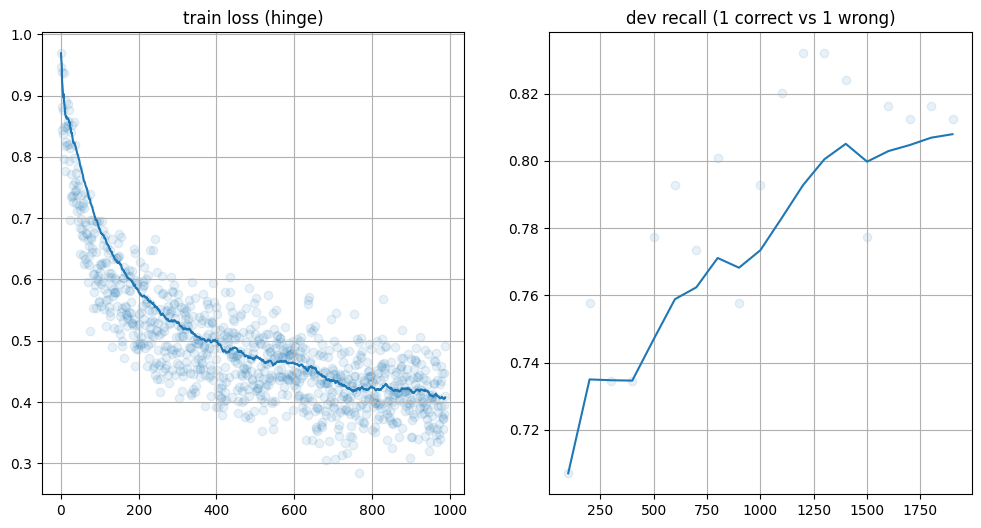

KeyboardInterrupt: 

In [22]:
# vòng lặp huấn luyện vô hạn. Dừng thủ công hoặc cài đặt early stopping

for batch in iterate_minibatches(train, batch_size=256, cycle=True):

    # Thực hiện một bước huấn luyện
    # 1) Xóa gradient cũ còn lưu trong model
    optimizer.zero_grad()

    # 2) SỬA Ở ĐÂY: Thêm hàm list() để ép kiểu numpy array về list cho tokenizer
    v_questions = question_vectorizer(list(batch['questions']))
    v_correct = answer_vectorizer(list(batch['correct_answers']))
    v_incorrect = answer_vectorizer(list(batch['wrong_answers']))

    # 3) Tính triplet loss (lấy trung bình theo batch)
    loss_t = torch.mean(compute_loss(v_questions, v_correct, v_incorrect, delta=1.0))

    # 4) Lan truyền ngược và cập nhật trọng số
    loss_t.backward()
    optimizer.step()

    loss_history.append(float(loss_t))

    if len(loss_history) % 50 == 0:
        # đo dev recall = P(correct_is_closer_than_wrong | q, a+, a-)
        dev_batch = next(dev_batches)
        
        # Lưu ý: Hàm get_recall ở turn trước bạn đã sửa list() bên trong nó rồi
        # nên ở đây truyền **dev_batch vào vẫn sẽ chạy bình thường.
        recall_t = get_recall(**dev_batch)

        dev_recall_history.append(recall_t)

    if len(loss_history) % 10 == 0:
        clear_output(True) # clear_output(True): Xóa khung hình cũ đi trước khi vẽ hình mới. Điều này tạo ra hiệu ứng ảnh động (animation) ngay trong Jupyter Notebook thay vì in ra hàng nghìn cái hình liên tiếp.
        plt.figure(figsize=[12, 6])
        plt.subplot(1, 2, 1), plt.title('train loss (hinge)'), plt.grid()
        plt.scatter(np.arange(len(loss_history)), loss_history, alpha=0.1) # plt.scatter(..., alpha=0.1): Vẽ các chấm tròn đại diện cho giá trị thô của từng bước. alpha=0.1 làm cho các chấm này mờ đi (trong suốt 90%), giúp biểu đồ không bị rối mắt khi có quá nhiều điểm dữ liệu.
        plt.plot(ewma(loss_history, span=100))
        plt.subplot(1, 2, 2), plt.title('dev recall (1 correct vs 1 wrong)'), plt.grid()
        dev_time = np.arange(1, len(dev_recall_history) + 1) * 100
        plt.scatter(dev_time, dev_recall_history, alpha=0.1)
        plt.plot(dev_time, ewma(dev_recall_history, span=10))
        plt.show()

In [23]:
print("Mean recall:", np.mean(dev_recall_history[-10:]))
assert np.mean(dev_recall_history[-10:]) > 0.85, "Please train for at least 85% recall on test set. "\
                                                  "You may need to change vectorizer model for that."
print("Well done!")

Mean recall: 0.813671875


AssertionError: Please train for at least 85% recall on test set. You may need to change vectorizer model for that.

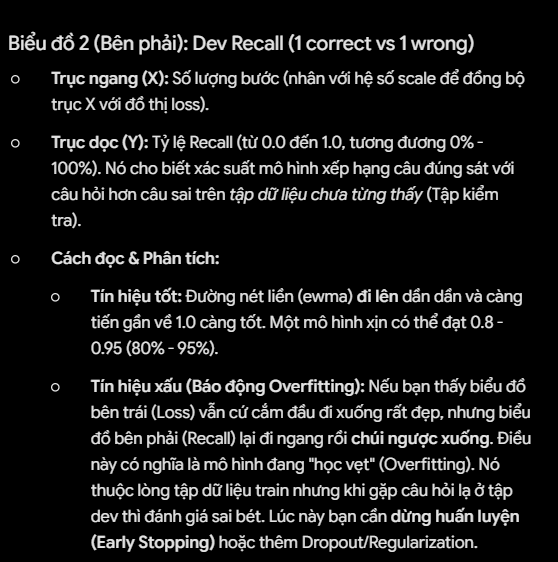

# Retriever evaluation (2 point)

Let's see how well does our model perform on actual question answering.

Given a question and a set of possible answers, pick answer with highest similarity to estimate accuracy.

In [24]:
# Chuẩn bị: chuyển model sang chế độ eval để tắt dropout khi đánh giá
question_vectorizer.eval()
answer_vectorizer.eval()

# tùy chọn: chuẩn bị thêm, ví dụ xây dựng index

def select_best_answer(question, possible_answers):
    """
    Dự đoán câu trả lời nào khớp nhất với câu hỏi.
    :param question: chuỗi chứa một câu hỏi
    :param possible_answers: danh sách chuỗi các câu trả lời khả dĩ
    :returns: số nguyên - chỉ số của câu trả lời tốt nhất trong possible_answers
    """
    # Vector hóa câu hỏi (1 câu) và toàn bộ các câu trả lời khả dĩ
    v_question = question_vectorizer([question])
    v_answers = answer_vectorizer(possible_answers)

    # Tính độ tương tự (dot product) giữa câu hỏi và từng câu trả lời
    scores = similarity(v_question, v_answers)

    # Chọn câu trả lời có độ tương tự cao nhất với câu hỏi
    best_index = int(torch.argmax(scores).item())
    return best_index


In [25]:
predicted_answers = [
    select_best_answer(question, possible_answers)
    for i, (question, possible_answers) in tqdm(test[['question', 'options']].iterrows(), total=len(test))
]

accuracy = np.mean([
    answer in correct_ix
    for answer, correct_ix in zip(predicted_answers, test['correct_indices'].values)
])
print("Accuracy: %0.5f" % accuracy)
assert accuracy > 0.65, "we need more accuracy!"
print("Great job!")

100%|██████████| 26970/26970 [12:09<00:00, 36.96it/s]

Accuracy: 0.67471
Great job!


In [31]:
def draw_results(question, possible_answers, predicted_index, correct_indices):
    print("Q:", question, end='\n\n')
    for i, answer in enumerate(possible_answers):
        print("#%i: %s %s" % (i, '[*]' if i == predicted_index else '[ ]', answer))

    print("\nVerdict:", "CORRECT" if predicted_index in correct_indices else "INCORRECT",
          "(ref: %s)" % correct_indices, end='\n' * 3)

In [27]:
for i in [1, 100, 1000, 2000, 3000, 4000, 5000]:
    draw_results(test.iloc[i].question, test.iloc[i].options,
                 predicted_answers[i], test.iloc[i].correct_indices)

Q: Which three countries did Beyonce's song "Work It Out" achieve top ten status?

#0: [ ] In July 2002, Beyoncé continued her acting career playing Foxxy Cleopatra alongside Mike Myers in the comedy film, Austin Powers in Goldmember, which spent its first weekend atop the US box office and grossed $73 million.
#1: [*] Beyoncé released "Work It Out" as the lead single from its soundtrack album which entered the top ten in the UK, Norway, and Belgium.
#2: [ ] In 2003, Beyoncé starred opposite Cuba Gooding, Jr., in the musical comedy The Fighting Temptations as Lilly, a single mother whom Gooding's character falls in love with.
#3: [ ] The film received mixed reviews from critics but grossed $30 million in the U.S. Beyoncé released "Fighting Temptation" as the lead single from the film's soundtrack album, with Missy Elliott, MC Lyte, and Free which was also used to promote the film.
#4: [ ] Another of Beyoncé's contributions to the soundtrack, "Summertime", fared better on the US charts.

In [28]:
# Ví dụ tự chọn: hỏi về màu sắc bầu trời, câu trả lời đúng là option đầu tiên (index 0).
question = "What color is the sky on a clear day?"  # câu hỏi của bạn ở đây!
possible_answers = [
    "The sky is blue on a clear day.",              # lựa chọn đúng (index 0)
    "Apples are usually red or green.",
    "The Earth orbits around the Sun.",
    "Dogs are known as man's best friend.",
]
# ^- các lựa chọn của bạn.
predicted_answer = select_best_answer(question, possible_answers)  # (đã sửa lỗi: predicted answer -> predicted_answer)

draw_results(question, possible_answers,
             predicted_answer, [0])


Q: What color is the sky on a clear day?

#0: [*] The sky is blue on a clear day.
#1: [ ] Apples are usually red or green.
#2: [ ] The Earth orbits around the Sun.
#3: [ ] Dogs are known as man's best friend.

Verdict: CORRECT (ref: [0])




In [30]:
import torch

# Lưu trọng số của mô hình vào file .pth
torch.save(question_vectorizer.state_dict(), 'question_vectorizer.pth')
torch.save(answer_vectorizer.state_dict(), 'answer_vectorizer.pth')

print("Đã lưu thành công weights của retriever!")

Đã lưu thành công weights của retriever!


### Part 2: to prompt a generator (3 points)

You have built a model that can select the most relevant sentence from a text document. However, this is still not the same as question answering - at least not how humans understand it. The full question answering system shoud answer your question in a dialogue - and perhap even let you ask follow-up questions.

Nhớ sau này luôn phải chạy trước xóa các biến lưu trữ trước khi load model mới không thôi là bị lỗi GPU phải load lại kernel

In [32]:
import gc
import torch

# 1. Xóa các biến của LLM cũ hoặc tensor dư thừa (Giữ lại tokenizer của BERT)
try:
    del model
    del input_ids
    del output_tokens
    del inputs
    # del tokenizer  <-- ĐÃ ĐÓNG TẮT: Không xóa cái này vì Retriever đang dùng
except NameError:
    pass 

# 2. Dọn rác RAM
gc.collect()

# 3. Dọn rác VRAM GPU
torch.cuda.empty_cache()

print(f"VRAM đang sử dụng: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB")
print(f"VRAM đang cache: {torch.cuda.memory_reserved() / (1024 ** 2):.2f} MB")

VRAM đang sử dụng: 456.25 MB
VRAM đang cache: 482.00 MB


In [34]:
import torch
import transformers

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Đảm bảo 2 vectorizer ở chế độ eval để dự đoán
question_vectorizer.eval()
answer_vectorizer.eval()

# =====================================================================
# TẢI GENERATOR (LLM QWEN)
# =====================================================================
model_name = 'Qwen/Qwen2-0.5B-Instruct'

# Dùng tên llm_tokenizer để LLM không ghi đè lên biến tokenizer của BERT
llm_tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
llm_tokenizer.pad_token_id = llm_tokenizer.eos_token_id

model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map='auto',
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

# =====================================================================
# KẾT HỢP VÀ DỰ ĐOÁN (Inference)
# =====================================================================
# Lấy mẫu số 10 từ tập train đang có sẵn trên RAM
pid, question, options, correct_indices, wrong_indices = train.iloc[10]

print('QUESTION:', question, '\n')
print('TEXT SENTENCES')
for i, cand in enumerate(options):
    print(['[ ]', '[v]'][i in correct_indices], cand)
print('-'*50)

# Dùng retriever chọn câu (các hàm và vectorizer vẫn hoạt động bình thường)
best_ix = select_best_answer(question, options)
best_sentence = options[best_ix]
print('Câu được retriever chọn:', best_sentence)
print('-'*50)

# Tự động dựng prompt
question_and_info = f"""
Question: {question}

Information: {best_sentence}
"""

# 1. Đổi tên biến thành inputs (vì nó chứa cả input_ids và attention_mask)
# Bật return_dict=True để đảm bảo luôn lấy được BatchEncoding dạng từ điển
inputs = llm_tokenizer.apply_chat_template([
    dict(role='user', content="You will be given a question and a piece of information that contains the answer. Please reply with a short informal answer to a question based on the information given."),
    dict(role='assistant', content="Okay, what question would you like me to answer?"),
    dict(role='user', content=question_and_info.strip())
], return_tensors='pt', return_dict=True, add_generation_prompt=True).to(device)

# 2. Sinh câu trả lời bằng LLM
# SỬA Ở ĐÂY: Bỏ torch.ones_like đi, truyền thẳng **inputs vào model
output_tokens = model.generate(
    **inputs, 
    max_new_tokens=64, 
    do_sample=True, 
    temperature=0.8, 
    top_p=0.9
)

print('LLM TRẢ LỜI:')
# 3. Lấy độ dài của câu prompt ban đầu để cắt bỏ đi, chỉ in ra phần model vừa tự trả lời
prompt_length = inputs['input_ids'].shape[1]
generated_tokens = output_tokens[0, prompt_length:]

# Dùng skip_special_tokens=True để kết quả in ra sạch sẽ hơn, không bị dính các ký tự lạ
print(llm_tokenizer.decode(generated_tokens, skip_special_tokens=True))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

QUESTION: What was the first album Beyoncé released as a solo artist? 

TEXT SENTENCES
[ ] Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress.
[ ] Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child.
[ ] Managed by her father, Mathew Knowles, the group became one of the world's best-selling girl groups of all time.
[v] Their hiatus saw the release of Beyoncé's debut album, Dangerously in Love (2003), which established her as a solo artist worldwide, earned five Grammy Awards and featured the Billboard Hot 100 number-one singles "Crazy in Love" and "Baby Boy".
--------------------------------------------------
Câu được retriever chọn: Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record p

In [ ]:
# import torch
# import torch.nn as nn
# import transformers
# import pandas as pd
# from transformers import AutoTokenizer, AutoModel

# # Khai báo thiết bị
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# print("Đang sử dụng:", device)

# # =====================================================================
# # PHẦN 1: TẢI LẠI RETRIEVER VÀ CÁC HÀM CẦN THIẾT
# # =====================================================================

# # 1.1 Tải lại BERT gốc và tokenizer của BERT
# bert_model_name = 'sentence-transformers/bert-base-nli-mean-tokens'
# tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
# bert = AutoModel.from_pretrained(bert_model_name)

# # 1.2 Khai báo lại class Vectorizer
# class Vectorizer(nn.Module):
#     def __init__(self, hid_size=256, bert=bert):
#         super().__init__()
#         self.bert = bert
#         self.hid_size = hid_size
#         self.fc1 = nn.Linear(768, 512)
#         self.fc2 = nn.Linear(512, self.hid_size) 
#         self.dropout = nn.Dropout(0.2)

#         for param in self.bert.parameters():
#             param.requires_grad_(False)
#         self.bert.eval()

#     def forward(self, input_phrases):
#         batch_tensors = tokenizer(
#             input_phrases,
#             padding=True,
#             truncation=True,
#             return_tensors="pt",
#         ).to(next(self.bert.parameters()).device) 

#         with torch.no_grad():
#             self.bert.eval() 
#             token_embs = self.bert(**batch_tensors).last_hidden_state

#         mask = batch_tensors["attention_mask"][..., None].to(torch.float32)
#         phrase_embs = (token_embs * mask).sum(1) / mask.sum(1)

#         phrase_embs = self.dropout(phrase_embs) 
#         phrase_embs = torch.relu(self.fc1(phrase_embs))
#         phrase_embs = self.dropout(phrase_embs)
#         phrase_embs = self.fc2(phrase_embs)
#         return phrase_embs

# # 1.3 Khai báo hàm tính độ tương tự (dot product)
# def similarity(v_question, v_answers):
#     # v_question shape: [1, hid_size]
#     # v_answers shape: [num_answers, hid_size]
#     # Nhân ma trận để tính dot product cho tất cả câu trả lời cùng lúc
#     return torch.matmul(v_question, v_answers.t())

# # 1.4 Khởi tạo 2 vectorizer và nạp trọng số đã lưu (Weights)
# question_vectorizer = Vectorizer(hid_size=256, bert=bert).to(device)
# answer_vectorizer = Vectorizer(hid_size=256, bert=bert).to(device)

# question_vectorizer.load_state_dict(torch.load('question_vectorizer.pth', map_location=device))
# answer_vectorizer.load_state_dict(torch.load('answer_vectorizer.pth', map_location=device))

# question_vectorizer.eval()
# answer_vectorizer.eval()

# def select_best_answer(question, possible_answers):
#     v_question = question_vectorizer([question])
#     v_answers = answer_vectorizer(possible_answers)
#     scores = similarity(v_question, v_answers)
#     best_index = int(torch.argmax(scores).item())
#     return best_index

# # =====================================================================
# # PHẦN 2: TẢI GENERATOR (LLM QWEN)
# # =====================================================================
# model_name = 'Qwen/Qwen2-0.5B-Instruct'

# # Dùng tên biến llm_tokenizer để không bị trùng với tokenizer của BERT ở trên
# llm_tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
# llm_tokenizer.pad_token_id = llm_tokenizer.eos_token_id

# model = transformers.AutoModelForCausalLM.from_pretrained(
#     model_name,
#     device_map='auto',
#     torch_dtype=torch.float16,
#     low_cpu_mem_usage=True,
# )

# # =====================================================================
# # PHẦN 3: KẾT HỢP VÀ DỰ ĐOÁN (Inference)
# # =====================================================================

# # LƯU Ý: Phải đảm bảo bạn đã load dataframe `train` trước bước này. 
# # Ví dụ: train = pd.read_json('đường_dẫn_file.json') 

# pid, question, options, correct_indices, wrong_indices = train.iloc[10]

# print('QUESTION:', question, '\n')
# print('TEXT SENTENCES')
# for i, cand in enumerate(options):
#     print(['[ ]', '[v]'][i in correct_indices], cand)
# print('-'*50)

# # Dùng retriever để chọn câu
# best_ix = select_best_answer(question, options)
# best_sentence = options[best_ix]
# print('Câu được retriever chọn:', best_sentence)
# print('-'*50)

# # Tự động dựng prompt
# question_and_info = f"""
# Question: {question}

# Information: {best_sentence}
# """

# input_ids = llm_tokenizer.apply_chat_template([
#     dict(role='user', content="You will be given a question and a piece of information that contains the answer. Please reply with a short informal answer to a question based on the information given."),
#     dict(role='assistant', content="Okay, what question would you like me to answer?"),
#     dict(role='user', content=question_and_info.strip())
# ], return_tensors='pt').to(device)

# # Sinh câu trả lời bằng LLM
# output_tokens = model.generate(
#     input_ids, 
#     attention_mask=torch.ones_like(input_ids),
#     max_new_tokens=64, 
#     do_sample=True, 
#     temperature=0.8, 
#     top_p=0.9
# )

# print('LLM TRẢ LỜI:')
# print(llm_tokenizer.decode(output_tokens[0, input_ids.shape[1]:]))

In [ ]:
# # note: you may want to save pre-trained retriever and restart to free memory
# import torch
# import transformers

# # model_name = 'TheBloke/Mistral-7B-Instruct-v0.2-GPTQ'  # feel free to choose any other model
# model_name = 'Qwen/Qwen2-0.5B-Instruct'
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# tokenizer = transformers.AutoTokenizer.from_pretrained(model_name, device_map=device)
# tokenizer.pad_token_id = tokenizer.eos_token_id
# model = transformers.AutoModelForCausalLM.from_pretrained(
#     model_name,
#     device_map='auto',
#     torch_dtype=torch.float16,
#     low_cpu_mem_usage=True,
# )

In [ ]:
# pid, question, options, correct_indices, wrong_indices = train.iloc[10]
# print('QUESTION', question, '\n')
# print('TEXT SENTENCES')
# for i, cand in enumerate(options):
#     print(['[ ]', '[v]'][i in correct_indices], cand)

In [ ]:
# # 1) Lấy một mẫu từ tập train: câu hỏi + các câu (options) trong cùng đoạn văn.
# pid, question, options, correct_indices, wrong_indices = train.iloc[10]

# # 2) Dùng retriever (đã huấn luyện) để chọn câu có khả năng chứa câu trả lời nhất.
# best_ix = select_best_answer(question, options)
# best_sentence = options[best_ix]
# print('Câu hỏi:', question)
# print('Câu được retriever chọn:', best_sentence)

# # 3) Tự động dựng prompt từ câu hỏi và câu đã chọn (không còn hardcode).
# question_and_info = f"""
# Question: {question}

# Information: {best_sentence}
# """

# input_ids = tokenizer.apply_chat_template([
#     dict(role='user', content="""You will be given a question and a piece of information that contains the answer. Please reply with a short informal answer to a question based on the information given.""".strip()),
#     dict(role='assistant', content="""Okay, what question would you like me to answer?"""),
#     dict(role='user', content=question_and_info.strip())], return_tensors='pt').to(device)
# # chi tiết: https://huggingface.co/docs/transformers/main/en/chat_templating ; chỉ dùng cho chat/instruct models

# output_tokens = model.generate(input_ids, attention_mask=torch.ones_like(input_ids),
#                                max_new_tokens=64, do_sample=True, temperature=0.8, top_p=0.9)
# print(tokenizer.decode(output_tokens[0, input_ids.shape[1]:]))


### Optional tasks for bonus points

There are many ways to improve our question answering model. Here's a bunch of things you can do to increase your understanding and get bonus points.

### 1.  Hard Negatives (2+ pts)

Not all wrong answers are equally wrong. As the training progresses, _most negative examples $a^-$ will be to easy._ So easy in fact, that loss function and gradients on such negatives is exactly __0.0__. To improve training efficiency, one can __mine hard negative samples__.

Given a list of answers,
* __Hard negative__ is the wrong answer with highest similarity with question,

$$a^-_{hard} = \underset {a^-} {argmax} \space sim[V_q(q), V_a(a^-)]$$

* __Semi-hard negative__ is the one with highest similarity _among wrong answers that are farther than positive one. This option is more useful if some wrong answers may actually be mislabelled correct answers.

* One can also __sample__ negatives proportionally to $$P(a^-_i) \sim e ^ {sim[V_q(q), V_a(a^-_i)]}$$


The task is to implement at least __hard negative__ sampling and apply it for model training.


### 2. Better prompting (2+ pts)

In the previous example, we manually engineer a prompt for an LLM to solve produce an answer. However, by this point you know multiple ways to make LLM do your bidding. In this assignment, you should try at least some of them:
- try few-shot learning with several handcrafted examples (or hand-picked model inputs)
- compare several instruct and/or non-instruct models; for non-instruct models
  - please not that you should not use apply_chat_template for non-instruct models
- provide some means of quality evaluation to compare your approach against the default one

At the minimum, several (10-20) side-by-side examples would do the trick. However, we'd appreciate creative means of evaluation here (crowdsourcing, asking another LM, anything exotic as long as you can explain it).

### 3. Search engine (3+ pts)

Our basic model only selects answers from 2-5 available sentences in paragraph. You can extend it to search over __the whole dataset__. All sentences in all other paragraphs are viable answers.

The goal is to train such a model and use it to __quickly find top-10 answers from the whole set__.

* You can ask such model a question of your own making - to see which answers it can find among the entire training dataset or even the entire wikipedia.
* Searching for top-K neighbors is easier if you use specialized methods: [KD-Tree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html) or [HNSW](https://github.com/nmslib/hnswlib).
* This task is much easier to train if you use hard or semi-hard negatives. You can even find hard negatives for one question from correct answers to other questions in batch - do so in-graph for maximum efficiency. See [1.] for more details.
